# ==================================================
# SUPPLY CHAIN & INVENTORY OPTIMIZATION ANALYTICS
# Python Data Cleaning & Preparation
# ==================================================

In [4]:
# ==================================================
# Load Cleaned CSV Files
# ==================================================

import pandas as pd
import numpy as np

# ==================================================
# Reload Files Using Semicolon Separator
# ==================================================

customers = pd.read_csv(
    "customers_clean.csv",
    sep=";"
)

orders = pd.read_csv(
    "orders_final.csv",
    sep=";"
)

inventory = pd.read_csv(
    "inventory_clean.csv",
    sep=";"
)

shipping = pd.read_csv(
    "shipping_clean.csv",
    sep=";"
)

products = pd.read_csv("products.csv")

suppliers = pd.read_csv("suppliers.csv")

warehouses = pd.read_csv("warehouses.csv")

In [5]:
# ==================================================
# Check Column Names
# ==================================================

for name, df in {
    "customers": customers,
    "orders": orders,
    "inventory": inventory,
    "shipping": shipping,
    "products": products,
    "suppliers": suppliers,
    "warehouses": warehouses
}.items():

    print("\n" + "="*50)
    print(name.upper())
    print("="*50)

    print(df.columns.tolist())


CUSTOMERS
['customer_id', 'customer_name', 'customer_segment', 'city', 'state', 'join_date', 'join_date_clean', 'rn', 'missing_city_flag', 'city_clean']

ORDERS
['order_id', 'order_date', 'customer_id', 'product_id', 'warehouse_id', 'supplier_id', 'quantity_ordered', 'unit_price', 'unit_cost', 'sales_amount', 'cost_amount', 'profit', 'order_status', 'shipping_days', 'delivery_date', 'order_date_clean', 'delivery_date_clean', 'rn', 'missing_delivery_date_flag']

INVENTORY
['inventory_id', 'snapshot_date', 'warehouse_id', 'product_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'inventory_value', 'days_of_inventory', 'snapshot_date_clean']

SHIPPING
['shipment_id', 'order_id', 'warehouse_id', 'carrier_name', 'dispatch_date', 'delivery_date', 'shipping_cost', 'shipping_status', 'dispatch_date_clean', 'delivery_date_clean', 'rn']

PRODUCTS
['product_id', 'product_name', 'category', 'subcategory', 'brand', 'launch_date', 'reorder_point', 'lead_time_days', 'product_status']

SUPPLIER

In [6]:
# ==================================================
# Dataset Dimensions
# ==================================================

for name, df in {
    "customers": customers,
    "orders": orders,
    "inventory": inventory,
    "shipping": shipping,
    "products": products,
    "suppliers": suppliers,
    "warehouses": warehouses
}.items():

    print(f"{name}: {df.shape}")

customers: (3000, 10)
orders: (14394, 19)
inventory: (7866, 10)
shipping: (12000, 11)
products: (500, 9)
suppliers: (150, 9)
warehouses: (50, 7)


In [7]:
# ==================================================
# Missing Values Summary
# ==================================================

for name, df in {
    "customers": customers,
    "orders": orders,
    "inventory": inventory,
    "shipping": shipping,
    "products": products,
    "suppliers": suppliers,
    "warehouses": warehouses
}.items():

    print("\n")
    print(name.upper())

    print(df.isnull().sum())



CUSTOMERS
customer_id          0
customer_name        0
customer_segment     0
city                 0
state                0
join_date            0
join_date_clean      0
rn                   0
missing_city_flag    0
city_clean           0
dtype: int64


ORDERS
order_id                         0
order_date                       0
customer_id                   1458
product_id                       0
warehouse_id                     0
supplier_id                   1445
quantity_ordered                 0
unit_price                       0
unit_cost                        0
sales_amount                     0
cost_amount                      0
profit                           0
order_status                     0
shipping_days                 1422
delivery_date                 1429
order_date_clean                 0
delivery_date_clean           1429
rn                               0
missing_delivery_date_flag       0
dtype: int64


INVENTORY
inventory_id             0
snapshot_date      

In [8]:
# ==================================================
# Display All Column Names
# ==================================================

for name, df in {
    "customers": customers,
    "orders": orders,
    "inventory": inventory,
    "shipping": shipping,
    "products": products,
    "suppliers": suppliers,
    "warehouses": warehouses
}.items():

    print("\n" + "="*60)
    print(name.upper())
    print("="*60)

    for col in df.columns:
        print(col)


CUSTOMERS
customer_id
customer_name
customer_segment
city
state
join_date
join_date_clean
rn
missing_city_flag
city_clean

ORDERS
order_id
order_date
customer_id
product_id
warehouse_id
supplier_id
quantity_ordered
unit_price
unit_cost
sales_amount
cost_amount
profit
order_status
shipping_days
delivery_date
order_date_clean
delivery_date_clean
rn
missing_delivery_date_flag

INVENTORY
inventory_id
snapshot_date
warehouse_id
product_id
stock_on_hand
reorder_point
safety_stock
inventory_value
days_of_inventory
snapshot_date_clean

SHIPPING
shipment_id
order_id
warehouse_id
carrier_name
dispatch_date
delivery_date
shipping_cost
shipping_status
dispatch_date_clean
delivery_date_clean
rn

PRODUCTS
product_id
product_name
category
subcategory
brand
launch_date
reorder_point
lead_time_days
product_status

SUPPLIERS
supplier_id
supplier_name
supplier_city
supplier_state
supplier_rating
contract_start_date
on_time_delivery_rate
quality_score
supplier_status

WAREHOUSES
warehouse_id
warehouse_na

In [9]:
# ==================================================
# Convert Date Columns To Datetime
# ==================================================

customers["join_date_clean"] = pd.to_datetime(
    customers["join_date_clean"],
    errors="coerce"
)

orders["order_date_clean"] = pd.to_datetime(
    orders["order_date_clean"],
    errors="coerce"
)

orders["delivery_date_clean"] = pd.to_datetime(
    orders["delivery_date_clean"],
    errors="coerce"
)

inventory["snapshot_date_clean"] = pd.to_datetime(
    inventory["snapshot_date_clean"],
    errors="coerce"
)

shipping["dispatch_date_clean"] = pd.to_datetime(
    shipping["dispatch_date_clean"],
    errors="coerce"
)

shipping["delivery_date_clean"] = pd.to_datetime(
    shipping["delivery_date_clean"],
    errors="coerce"
)

In [10]:
# ==================================================
# Remove Remaining Duplicates
# ==================================================

customers = customers.drop_duplicates()

orders = orders.drop_duplicates()

inventory = inventory.drop_duplicates()

shipping = shipping.drop_duplicates()

products = products.drop_duplicates()

suppliers = suppliers.drop_duplicates()

warehouses = warehouses.drop_duplicates()

In [11]:
# ==================================================
# Missing Value Analysis
# ==================================================

for name, df in {
    "customers": customers,
    "orders": orders,
    "inventory": inventory,
    "shipping": shipping,
    "products": products,
    "suppliers": suppliers,
    "warehouses": warehouses
}.items():

    print("\n" + "="*50)
    print(name.upper())
    print("="*50)

    print(df.isnull().sum())


CUSTOMERS
customer_id          0
customer_name        0
customer_segment     0
city                 0
state                0
join_date            0
join_date_clean      0
rn                   0
missing_city_flag    0
city_clean           0
dtype: int64

ORDERS
order_id                         0
order_date                       0
customer_id                   1458
product_id                       0
warehouse_id                     0
supplier_id                   1445
quantity_ordered                 0
unit_price                       0
unit_cost                        0
sales_amount                     0
cost_amount                      0
profit                           0
order_status                     0
shipping_days                 1422
delivery_date                 1429
order_date_clean                 0
delivery_date_clean           1429
rn                               0
missing_delivery_date_flag       0
dtype: int64

INVENTORY
inventory_id             0
snapshot_date         

In [12]:
# ==================================================
# Fill Important Missing Values
# ==================================================

customers["city"] = customers["city"].fillna("Unknown")

customers["state"] = customers["state"].fillna("Unknown")

orders["shipping_days"] = orders["shipping_days"].fillna(
    orders["shipping_days"].median()
)

In [13]:
# ==================================================
# Standardize Text Casing
# ==================================================

customers["city"] = customers["city"].str.title()

customers["state"] = customers["state"].str.title()

products["category"] = products["category"].str.title()

products["subcategory"] = products["subcategory"].str.title()

In [14]:
# ==================================================
# Detect & Remove Extreme Sales Outliers
# ==================================================

Q1 = orders["sales_amount"].quantile(0.25)

Q3 = orders["sales_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

orders = orders[
    (orders["sales_amount"] >= lower_bound)
    &
    (orders["sales_amount"] <= upper_bound)
]

print("Rows after outlier removal:", len(orders))

Rows after outlier removal: 13949


In [15]:
# ==================================================
# Profit Margin Percentage
# ==================================================

orders["profit_margin_pct"] = (
    orders["profit"] /
    orders["sales_amount"]
) * 100

In [16]:
# ==================================================
# Delay Flag
# ==================================================

orders["delay_flag"] = np.where(
    orders["shipping_days"] > 7,
    1,
    0
)

In [17]:
# ==================================================
# Stockout Flag
# ==================================================

inventory["stockout_flag"] = np.where(
    inventory["stock_on_hand"] <= inventory["reorder_point"],
    1,
    0
)

In [18]:
# ==================================================
# Days Since Last Order
# ==================================================

latest_order = orders["order_date_clean"].max()

orders["days_since_last_order"] = (
    latest_order -
    orders["order_date_clean"]
).dt.days

In [19]:
# ==================================================
# Verify Engineered Columns
# ==================================================

orders[
    [
        "profit",
        "sales_amount",
        "profit_margin_pct",
        "shipping_days",
        "delay_flag",
        "days_since_last_order"
    ]
].head()

,profit,sales_amount,profit_margin_pct,shipping_days,delay_flag,days_since_last_order
0,565762.19,2932328.07,19.293959,59.0,1,723
1,2300627.91,9122494.64,25.219285,5.0,0,768
2,2424486.13,12377908.18,19.587204,5.0,0,755
3,9207678.42,22098277.48,41.666951,5.0,0,564
4,71750.34,519420.14,13.813546,50.0,1,745


In [20]:
# ==================================================
# Merge Orders With Customers
# ==================================================

master_df = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="left"
)

print(master_df.shape)

(13949, 31)


In [21]:
# ==================================================
# Merge Products
# ==================================================

master_df = pd.merge(
    master_df,
    products,
    on="product_id",
    how="left"
)

print(master_df.shape)

(13949, 39)


In [22]:
# ==================================================
# Merge Suppliers
# ==================================================

master_df = pd.merge(
    master_df,
    suppliers,
    on="supplier_id",
    how="left"
)

print(master_df.shape)

(13949, 47)


In [23]:
# ==================================================
# Merge Warehouses
# ==================================================

master_df = pd.merge(
    master_df,
    warehouses,
    on="warehouse_id",
    how="left"
)

print(master_df.shape)

(13949, 53)


In [24]:
# ==================================================
# Merge Shipping Information
# ==================================================

master_df = pd.merge(
    master_df,
    shipping,
    on="order_id",
    how="left"
)

print(master_df.shape)

(16958, 63)


In [25]:
# ==================================================
# Master Dataset Information
# ==================================================

master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16958 entries, 0 to 16957
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   order_id                    16958 non-null  object        
 1   order_date                  16958 non-null  object        
 2   customer_id                 15232 non-null  object        
 3   product_id                  16958 non-null  object        
 4   warehouse_id_x              16958 non-null  object        
 5   supplier_id                 15237 non-null  object        
 6   quantity_ordered            16958 non-null  int64         
 7   unit_price                  16958 non-null  float64       
 8   unit_cost                   16958 non-null  float64       
 9   sales_amount                16958 non-null  float64       
 10  cost_amount                 16958 non-null  float64       
 11  profit                      16958 non-null  float64   

In [26]:
# ==================================================
# Master Dataset Shape
# ==================================================

print(master_df.shape)

(16958, 63)


In [27]:
# ==================================================
# First Five Rows
# ==================================================

master_df.head()

,order_id,order_date,customer_id,product_id,warehouse_id_x,supplier_id,quantity_ordered,unit_price,unit_cost,sales_amount,...,shipment_id,warehouse_id_y,carrier_name,dispatch_date,delivery_date_y,shipping_cost,shipping_status,dispatch_date_clean,delivery_date_clean_y,rn
0,ORD000001,07/04/2024,C01963,P0401,W020,S0025,259,11321.73,9137.32,2932328.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
1,ORD000002,22/02/2024,C02190,P0047,W006,S0090,497,18355.12,13726.09,9122494.64,...,SHP000445,W020,DTDC,2023-12-04,NaN,1018.99,In Transit,2023-12-04,NaT,1.0
2,ORD000003,06-03-2024,C00238,P0487,W037,S0134,319,38802.22,31201.95,12377908.18,...,SHP010103,W014,XpressBees,2024-08-20,2024-09-16,1984.99,Delivered,2024-08-20,2024-09-16,1.0
3,ORD000004,2024-09-13,C01888,P0362,W023,S0046,454,48674.62,28393.39,22098277.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
4,ORD000005,16-03-2024,C00804,P0276,W035,S0017,106,4900.19,4223.30,519420.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN


In [28]:
# ==================================================
# Check Missing Customers
# ==================================================

print(
    "Missing Customer Records:",
    master_df["customer_name"].isna().sum()
)

Missing Customer Records: 1726


In [29]:
# ==================================================
# Check Missing Products
# ==================================================

print(
    "Missing Product Records:",
    master_df["product_name"].isna().sum()
)

Missing Product Records: 0


In [30]:
# ==================================================
# Check Missing Suppliers
# ==================================================

print(
    "Missing Supplier Records:",
    master_df["supplier_name"].isna().sum()
)

Missing Supplier Records: 1721


In [31]:
# ==================================================
# Check Missing Warehouse Records
# ==================================================

print(
    "Missing Warehouse Records:",
    master_df["warehouse_name"].isna().sum()
)

Missing Warehouse Records: 0


In [32]:
# ==================================================
# Overall Missing Values
# ==================================================

master_df.isnull().sum().sort_values(
    ascending=False
).head(20)

delivery_date_y          8540
delivery_date_clean_y    8540
carrier_name             7564
shipping_cost            6726
warehouse_id_y           6726
shipping_status          6726
shipment_id              6726
dispatch_date            6726
rn                       6726
dispatch_date_clean      6726
on_time_delivery_rate    2679
supplier_rating          2366
customer_id              1726
state_x                  1726
join_date                1726
customer_segment         1726
city_x                   1726
customer_name            1726
city_clean               1726
join_date_clean          1726
dtype: int64

In [33]:
# ==================================================
# Export Master Dataset
# ==================================================

master_df.to_csv(
    "master_supply_chain_dataset.csv",
    index=False
)

print("Master Dataset Exported Successfully")

Master Dataset Exported Successfully


In [34]:
# ==================================================
# Check Duplicate Order IDs In Shipping
# ==================================================

shipping["order_id"].duplicated().sum()

np.int64(4224)

In [35]:
# ==================================================
# Show Top Repeated Order IDs
# ==================================================

shipping["order_id"].value_counts().head(20)

order_id
ORD011198    6
ORD004622    5
ORD005640    5
ORD011929    5
ORD003536    5
ORD008757    5
ORD011384    5
ORD012037    5
ORD010345    5
ORD013930    5
ORD009363    4
ORD008402    4
ORD008550    4
ORD010513    4
ORD004849    4
ORD014856    4
ORD005729    4
ORD011603    4
ORD011240    4
ORD001464    4
Name: count, dtype: int64

In [36]:
# ==================================================
# Check Duplicate Customer IDs
# ==================================================

customers["customer_id"].duplicated().sum()

np.int64(0)

In [37]:
# ==================================================
# Check Duplicate Supplier IDs
# ==================================================

suppliers["supplier_id"].duplicated().sum()

np.int64(0)

In [38]:
# ==================================================
# Check Duplicate Product IDs
# ==================================================

products["product_id"].duplicated().sum()

np.int64(0)

In [39]:
# ==================================================
# Check Duplicate Warehouse IDs
# ==================================================

warehouses["warehouse_id"].duplicated().sum()

np.int64(0)

In [40]:
# ==================================================
# Missing Product Records
# ==================================================

print(
    "Missing Product Records:",
    master_df["product_name"].isna().sum()
)

Missing Product Records: 0


In [41]:
# ==================================================
# Missing Warehouse Records
# ==================================================

print(
    "Missing Warehouse Records:",
    master_df["warehouse_name"].isna().sum()
)

Missing Warehouse Records: 0


# EDA & VISUALIZATION SECTION

In [42]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
# ==================================================
# Monthly Revenue Trend
# ==================================================

monthly_revenue = (
    master_df
    .groupby(
        master_df["order_date_clean"].dt.to_period("M")
    )["sales_amount"]
    .sum()
)

plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

NameError: name 'plt' is not defined

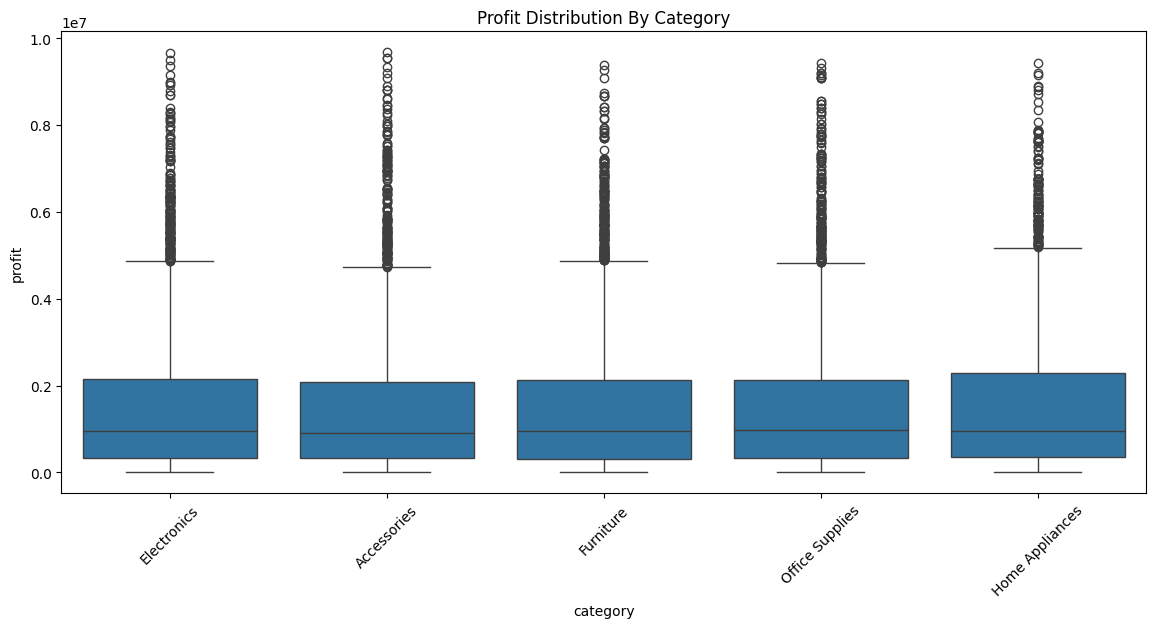

In [ ]:
# ==================================================
# Profit Distribution By Category
# ==================================================

plt.figure(figsize=(14,6))

sns.boxplot(
    data=master_df,
    x="category",
    y="profit"
)

plt.xticks(rotation=45)

plt.title("Profit Distribution By Category")

plt.show()

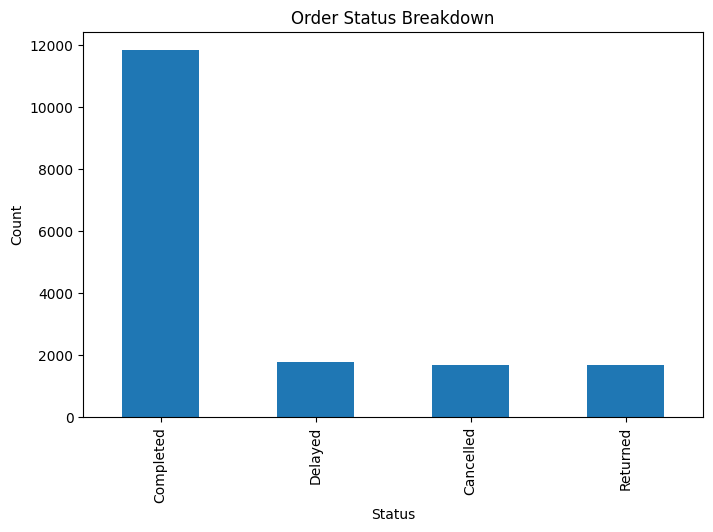

In [ ]:
# ==================================================
# Order Status Breakdown
# ==================================================

status_counts = (
    master_df["order_status"]
    .value_counts()
)

plt.figure(figsize=(8,5))

status_counts.plot(
    kind="bar"
)

plt.title("Order Status Breakdown")

plt.xlabel("Status")

plt.ylabel("Count")

plt.show()

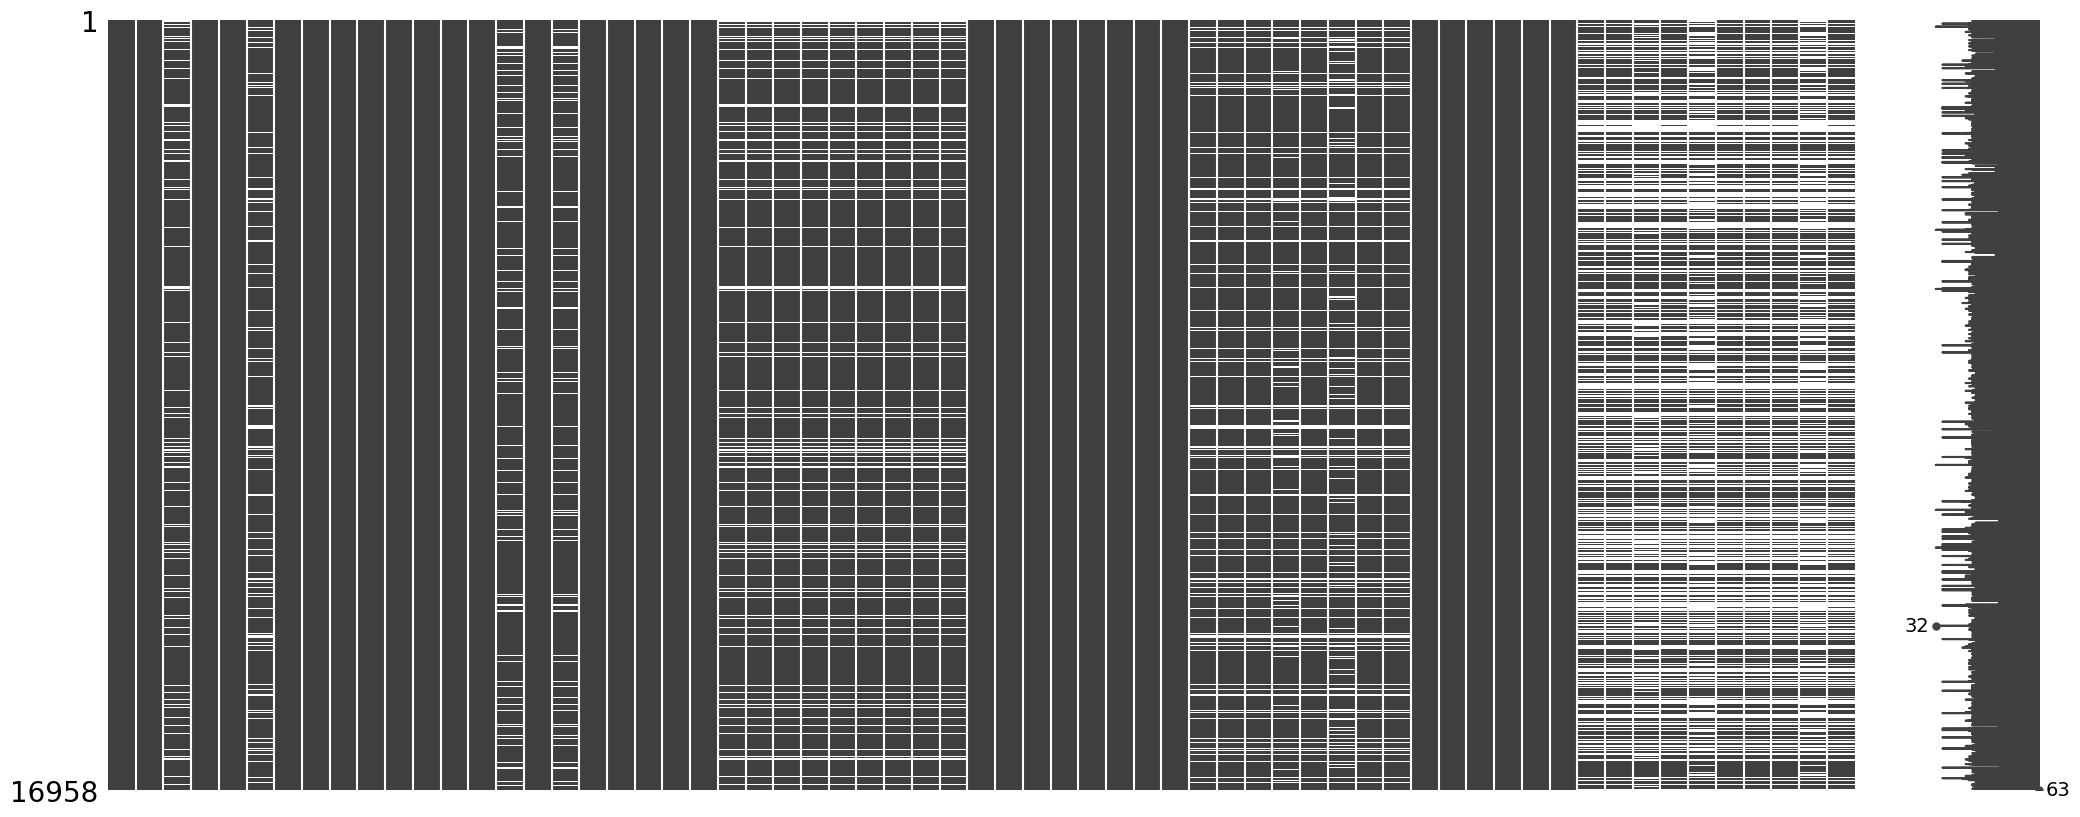

In [ ]:
# ==================================================
# Missing Value Heatmap
# ==================================================

import missingno as msno

msno.matrix(master_df)

plt.show()

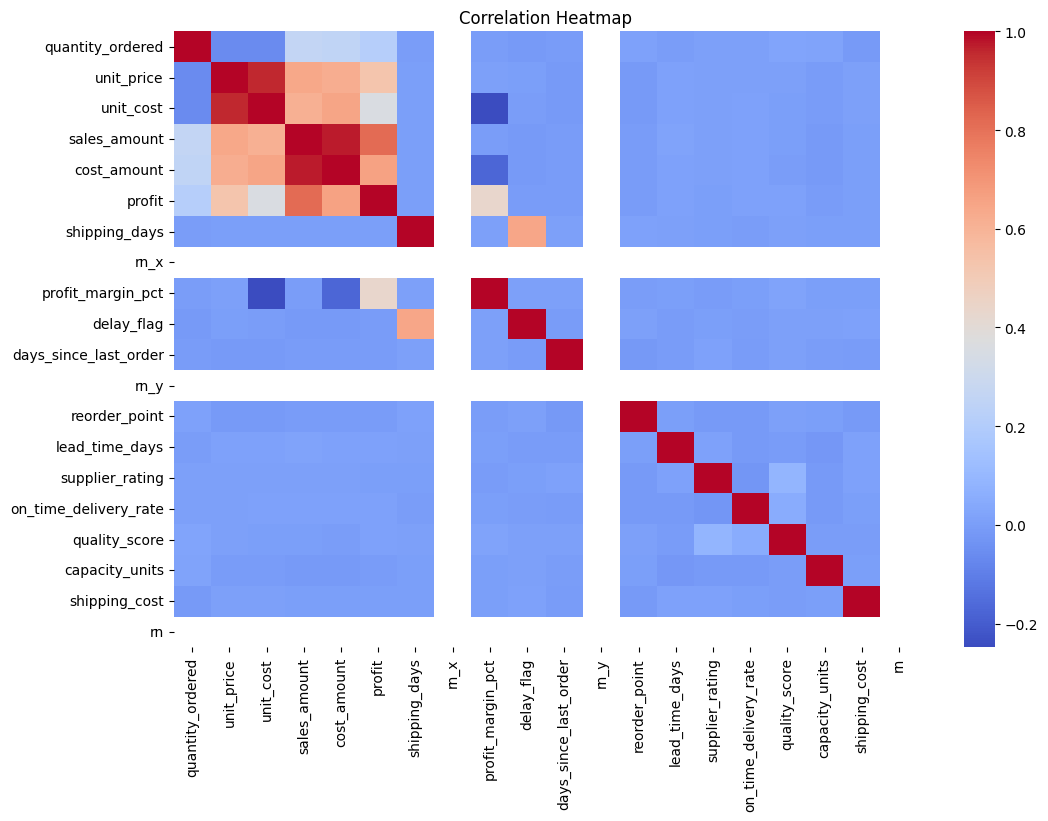

In [ ]:
# ==================================================
# Correlation Heatmap
# ==================================================

numeric_df = master_df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

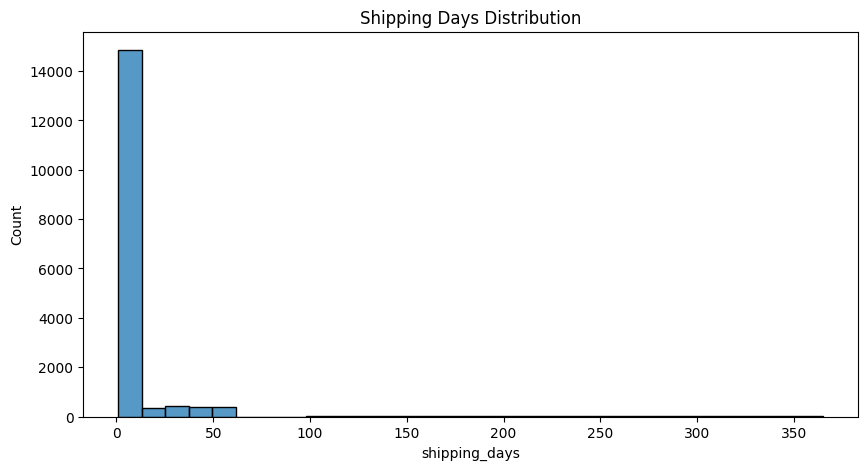

In [ ]:
# ==================================================
# Shipping Days Distribution
# ==================================================

plt.figure(figsize=(10,5))

sns.histplot(
    master_df["shipping_days"],
    bins=30
)

plt.title("Shipping Days Distribution")

plt.show()

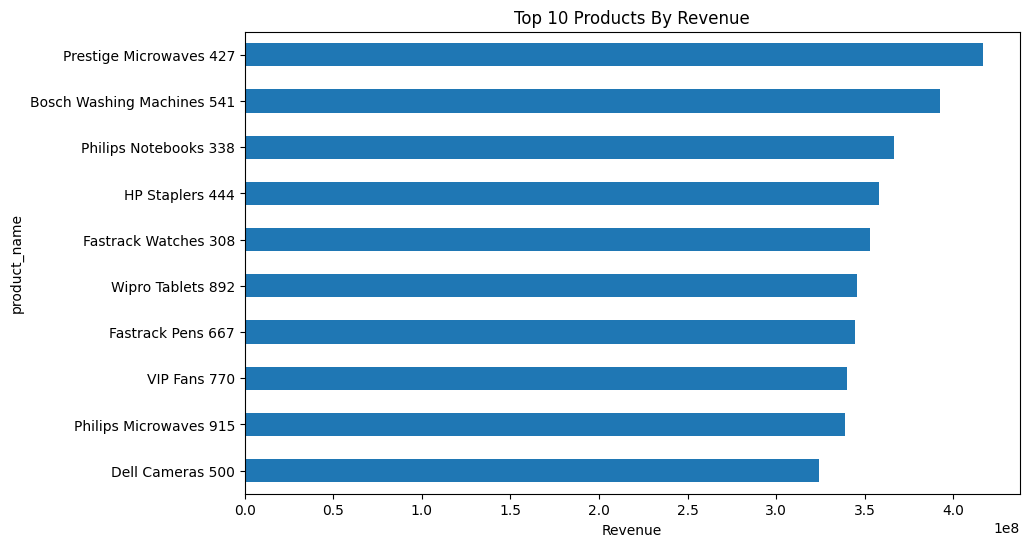

In [ ]:
# ==================================================
# Top 10 Products By Revenue
# ==================================================

top_products = (
    master_df
    .groupby("product_name")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products By Revenue")

plt.xlabel("Revenue")

plt.show()

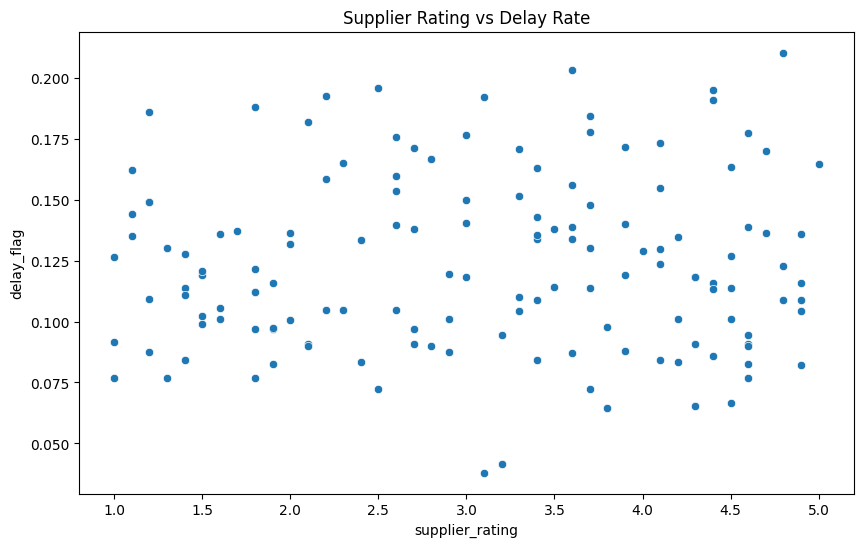

In [ ]:
# ==================================================
# Supplier Rating vs Delay Rate
# ==================================================

supplier_analysis = (
    master_df
    .groupby("supplier_name")
    .agg({
        "supplier_rating":"mean",
        "delay_flag":"mean"
    })
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=supplier_analysis,
    x="supplier_rating",
    y="delay_flag"
)

plt.title(
    "Supplier Rating vs Delay Rate"
)

plt.show()

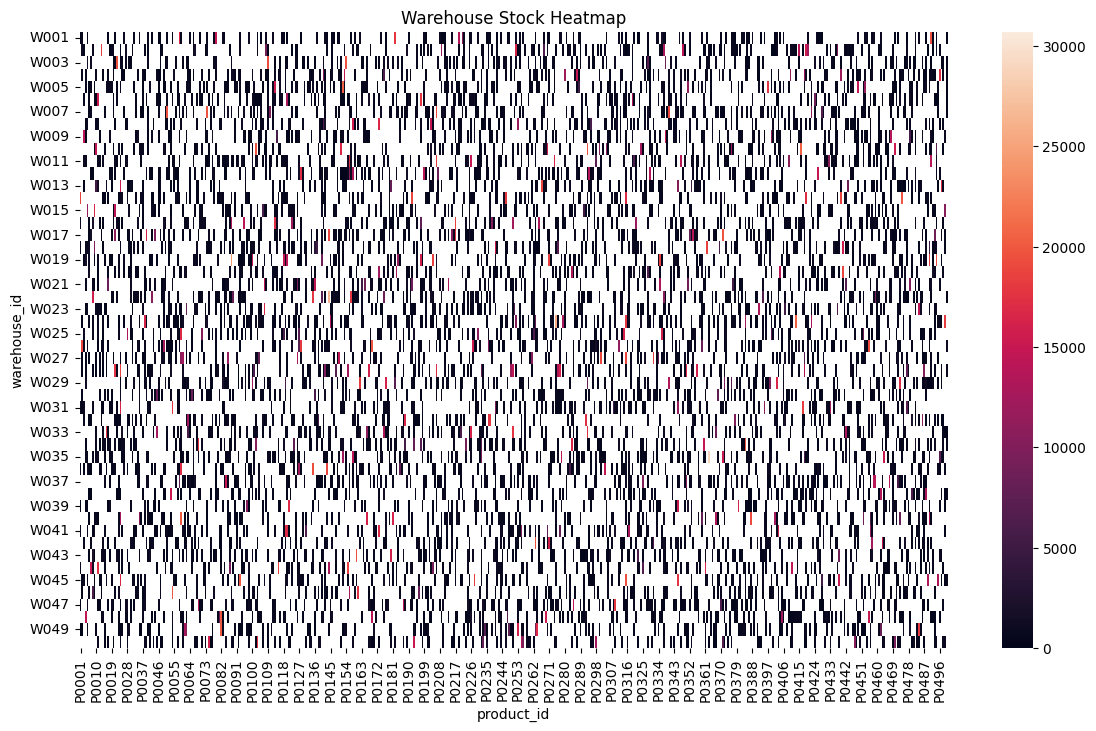

In [ ]:
# ==================================================
# Warehouse Stock Levels
# ==================================================

warehouse_stock = (
    inventory
    .pivot_table(
        values="stock_on_hand",
        index="warehouse_id",
        columns="product_id",
        aggfunc="sum"
    )
)

plt.figure(figsize=(14,8))

sns.heatmap(
    warehouse_stock,
    cbar=True
)

plt.title("Warehouse Stock Heatmap")

plt.show()

In [ ]:
# ==================================================
# Revenue By Category × Month
# ==================================================

pivot_revenue = pd.pivot_table(
    master_df,
    values="sales_amount",
    index="category",
    columns=master_df["order_date_clean"].dt.to_period("M"),
    aggfunc="sum"
)

pivot_revenue

order_date_clean,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,...,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03
category,,,,,,,,,,,,,,,,,,,,,
Accessories,4.746013e+08,4.230290e+08,7.219745e+08,5.613503e+08,5.058942e+08,4.811228e+08,7.758660e+08,4.427205e+08,7.484494e+08,5.634865e+08,...,5.143409e+08,6.621177e+08,5.755657e+08,7.253328e+08,7.703310e+08,5.980665e+08,5.864285e+08,1.312976e+08,1.533379e+08,1.390630e+08
Electronics,6.545700e+08,5.370254e+08,4.706457e+08,5.479265e+08,6.017281e+08,5.444221e+08,6.473338e+08,5.790752e+08,5.153010e+08,6.492775e+08,...,4.629226e+08,5.962687e+08,4.606307e+08,3.376682e+08,6.701941e+08,4.742105e+08,5.214606e+08,1.094927e+08,1.184095e+08,1.770863e+08
Furniture,5.195132e+08,4.341879e+08,5.282011e+08,5.473988e+08,6.145911e+08,4.847423e+08,6.004068e+08,4.834708e+08,4.970032e+08,5.939811e+08,...,4.572190e+08,5.647292e+08,6.114614e+08,5.138721e+08,4.946261e+08,4.673858e+08,5.029690e+08,1.293611e+08,1.000946e+08,1.704685e+08
Home Appliances,6.766967e+08,4.451038e+08,3.389161e+08,7.392382e+08,5.920587e+08,5.768177e+08,5.383153e+08,6.182073e+08,3.855639e+08,4.434599e+08,...,5.463809e+08,6.995447e+08,5.826255e+08,7.022322e+08,5.002458e+08,5.205588e+08,4.878944e+08,1.383964e+08,6.847189e+07,6.988753e+07
Office Supplies,5.706875e+08,5.439246e+08,6.010303e+08,5.006911e+08,7.216892e+08,5.394970e+08,5.580643e+08,5.055126e+08,4.785251e+08,3.818826e+08,...,6.361090e+08,4.994282e+08,4.835076e+08,6.316034e+08,5.912950e+08,5.696821e+08,5.826572e+08,3.072713e+07,9.965370e+07,1.554537e+08


In [ ]:
# ==================================================
# Supplier Delay Rate
# ==================================================

pivot_supplier = pd.pivot_table(
    master_df,
    values="delay_flag",
    index="supplier_name",
    aggfunc="mean"
)

pivot_supplier

,delay_flag
supplier_name,
Supplier_0001 Ltd,0.118182
Supplier_0002 Pvt Ltd,0.130000
Supplier_0003 Pvt Ltd,0.100917
Supplier_0004 Pvt Ltd,0.090909
Supplier_0005 Pvt Ltd,0.127119
...,...
Supplier_0146 Pvt Ltd,0.150000
Supplier_0147 Ltd,0.170000
Supplier_0148 Ltd,0.192661


In [ ]:
# ==================================================
# Warehouse × Product Category × Stock Level
# ==================================================

inventory_analysis = inventory.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

inventory_analysis = inventory_analysis.merge(
    warehouses[["warehouse_id", "warehouse_name"]],
    on="warehouse_id",
    how="left"
)

warehouse_category_stock = pd.pivot_table(
    inventory_analysis,
    values="stock_on_hand",
    index="warehouse_name",
    columns="category",
    aggfunc="sum"
)

warehouse_category_stock

category,Accessories,Electronics,Furniture,Home Appliances,Office Supplies
warehouse_name,,,,,
WH-AHM-07,31494.0,21714.0,30043.0,56544.0,23908.0
WH-AHM-17,43124.0,43874.0,35741.0,27171.0,44316.0
WH-AHM-37,13206.0,10608.0,48825.0,37312.0,51474.0
WH-AHM-47,46733.0,10988.0,28342.0,17064.0,30465.0
WH-BAN-02,58086.0,60974.0,22652.0,20127.0,39955.0
WH-BAN-22,55240.0,53117.0,46791.0,28197.0,27225.0
WH-BAN-32,20182.0,30871.0,30090.0,48387.0,35139.0
WH-CHE-13,27990.0,44021.0,8794.0,19602.0,32473.0
WH-CHE-23,21190.0,16292.0,10430.0,49185.0,34509.0


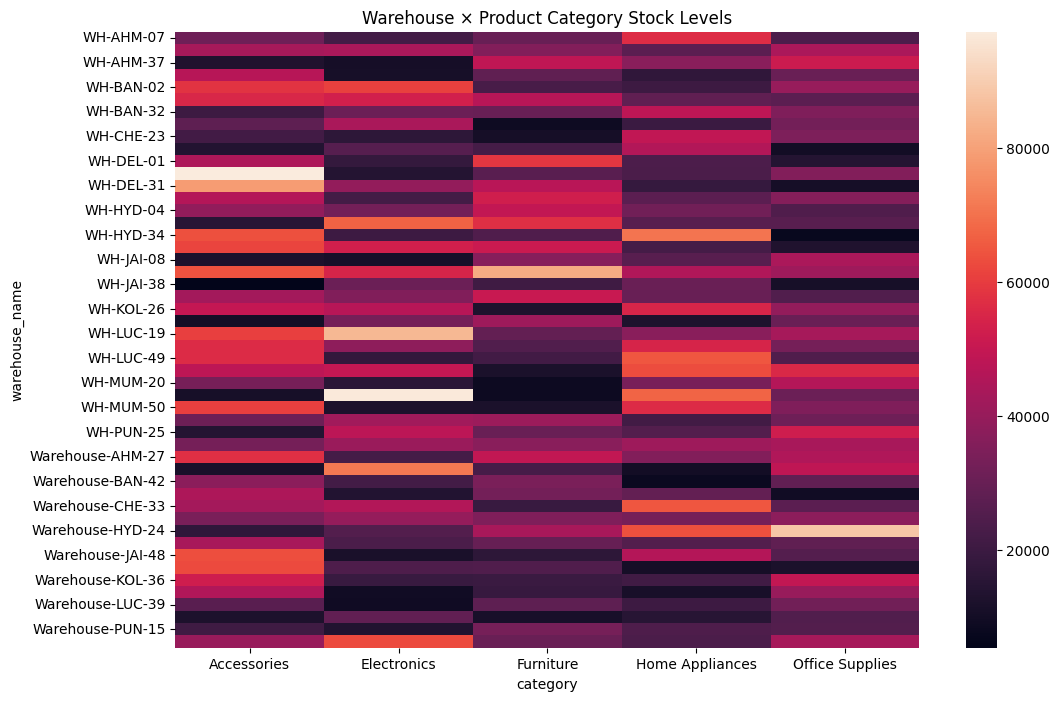

In [ ]:
# ==================================================
# Warehouse × Category Stock Heatmap
# ==================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    warehouse_category_stock,
    annot=False
)

plt.title(
    "Warehouse × Product Category Stock Levels"
)

plt.show()

In [ ]:
master_df.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'product_id',
 'warehouse_id_x',
 'supplier_id',
 'quantity_ordered',
 'unit_price',
 'unit_cost',
 'sales_amount',
 'cost_amount',
 'profit',
 'order_status',
 'shipping_days',
 'delivery_date_x',
 'order_date_clean',
 'delivery_date_clean_x',
 'rn_x',
 'missing_delivery_date_flag',
 'profit_margin_pct',
 'delay_flag',
 'days_since_last_order',
 'customer_name',
 'customer_segment',
 'city_x',
 'state_x',
 'join_date',
 'join_date_clean',
 'rn_y',
 'missing_city_flag',
 'city_clean',
 'product_name',
 'category',
 'subcategory',
 'brand',
 'launch_date',
 'reorder_point',
 'lead_time_days',
 'product_status',
 'supplier_name',
 'supplier_city',
 'supplier_state',
 'supplier_rating',
 'contract_start_date',
 'on_time_delivery_rate',
 'quality_score',
 'supplier_status',
 'warehouse_name',
 'city_y',
 'state_y',
 'capacity_units',
 'warehouse_manager',
 'warehouse_type',
 'shipment_id',
 'warehouse_id_y',
 'carrier_name',
 'dispatch_date',
 '

# ABC Analysis

In [ ]:
# ==================================================
# Product Revenue Calculation
# ==================================================

product_revenue = (
    master_df
    .groupby("product_name")["sales_amount"]
    .sum()
    .reset_index()
)

product_revenue = product_revenue.sort_values(
    by="sales_amount",
    ascending=False
)

product_revenue.rename(
    columns={"sales_amount":"revenue"},
    inplace=True
)

In [ ]:
# ==================================================
# Calculate Revenue Contribution %
# ==================================================

total_revenue = product_revenue["revenue"].sum()

product_revenue["revenue_pct"] = (
    product_revenue["revenue"] /
    total_revenue
) * 100

product_revenue["cumulative_pct"] = (
    product_revenue["revenue_pct"]
    .cumsum()
)

In [ ]:
# ==================================================
# ABC Classification
# ==================================================

def classify_abc(cum_pct):

    if cum_pct <= 80:
        return "A"

    elif cum_pct <= 95:
        return "B"

    else:
        return "C"

product_revenue["ABC_Class"] = (
    product_revenue["cumulative_pct"]
    .apply(classify_abc)
)

product_revenue.head()

,product_name,revenue,revenue_pct,cumulative_pct,ABC_Class
341,Prestige Microwaves 427,4.165661e+08,0.399664,0.399664,A
39,Bosch Washing Machines 541,3.923750e+08,0.376454,0.776118,A
301,Philips Notebooks 338,3.665470e+08,0.351674,1.127793,A
226,HP Staplers 444,3.578922e+08,0.343371,1.471163,A
125,Fastrack Watches 308,3.530550e+08,0.338730,1.809893,A


In [ ]:
# ==================================================
# ABC Class Summary
# ==================================================

product_revenue["ABC_Class"].value_counts()

ABC_Class
A    355
B    100
C     45
Name: count, dtype: int64

# INVENTORY TURNOVER

Inventory Turnover = Cost of Goods Sold / Average Inventory

In [ ]:
# ==================================================
# Product Level Inventory Turnover
# ==================================================

cogs = (
    master_df
    .groupby("product_id")["cost_amount"]
    .sum()
)

avg_inventory = (
    inventory
    .groupby("product_id")["inventory_value"]
    .mean()
)

inventory_turnover = pd.concat(
    [cogs, avg_inventory],
    axis=1
)

inventory_turnover.columns = [
    "COGS",
    "Average_Inventory"
]

inventory_turnover["Turnover_Ratio"] = (
    inventory_turnover["COGS"] /
    inventory_turnover["Average_Inventory"]
)

inventory_turnover.head()

,COGS,Average_Inventory,Turnover_Ratio
product_id,,,
P0001,1.378468e+08,1.324134e+07,10.410336
P0002,2.293850e+08,5.324372e+07,4.308207
P0003,1.993127e+08,1.773704e+07,11.237091
P0004,1.770522e+08,2.285219e+07,7.747712
P0005,2.571471e+08,3.162874e+07,8.130171


# Slow Moving SKU

In [ ]:
# ==================================================
# Slow Moving Products
# ==================================================

slow_moving = inventory[
    inventory["days_of_inventory"] > 90
]

slow_moving = slow_moving.merge(
    products[
        ["product_id","product_name"]
    ],
    on="product_id"
)

slow_moving[
    [
        "product_name",
        "days_of_inventory"
    ]
].head()

,product_name,days_of_inventory
0,Fastrack Monitors 679,286.8
1,Philips Fans 758,97.6
2,Bosch Wallets 405,237.3
3,Godrej Office Chairs 723,163.2
4,Bosch Pens 305,954.6


# Fast Moving SKU

In [ ]:
# ==================================================
# Fast Moving Products
# ==================================================

fast_moving = inventory[
    inventory["days_of_inventory"] < 30
]

fast_moving = fast_moving.merge(
    products[
        ["product_id","product_name"]
    ],
    on="product_id"
)

fast_moving.head()

,inventory_id,snapshot_date,warehouse_id,product_id,stock_on_hand,reorder_point,safety_stock,inventory_value,days_of_inventory,snapshot_date_clean,stockout_flag,product_name
0,INV000010,2023-11-29,W043,P0250,0.0,78,43,0.00,0.0,2023-11-29,1,Philips Mixers 631
1,INV000018,2024-01-25,W023,P0385,0.0,187,108,0.00,0.0,2024-01-25,1,Generic Mixers 717
2,INV000021,2025-05-22,W016,P0263,252.0,45,23,8634587.72,13.0,2025-05-22,0,Bosch Shelves 305
3,INV000022,2024-02-23,W040,P0460,85.0,19,5,3971206.87,5.7,2024-02-23,0,Wipro Headphones 283
4,INV000024,2025-10-23,W042,P0248,361.0,79,30,3086934.14,19.0,2025-10-23,0,Prestige Staplers 439


# Dead Stock

In [ ]:
# ==================================================
# Dead Stock Detection
# ==================================================

dead_stock = inventory[
    inventory["days_of_inventory"] > 90
]

dead_stock.shape

(2153, 11)

# MONTHLY DEMAND PATTERN

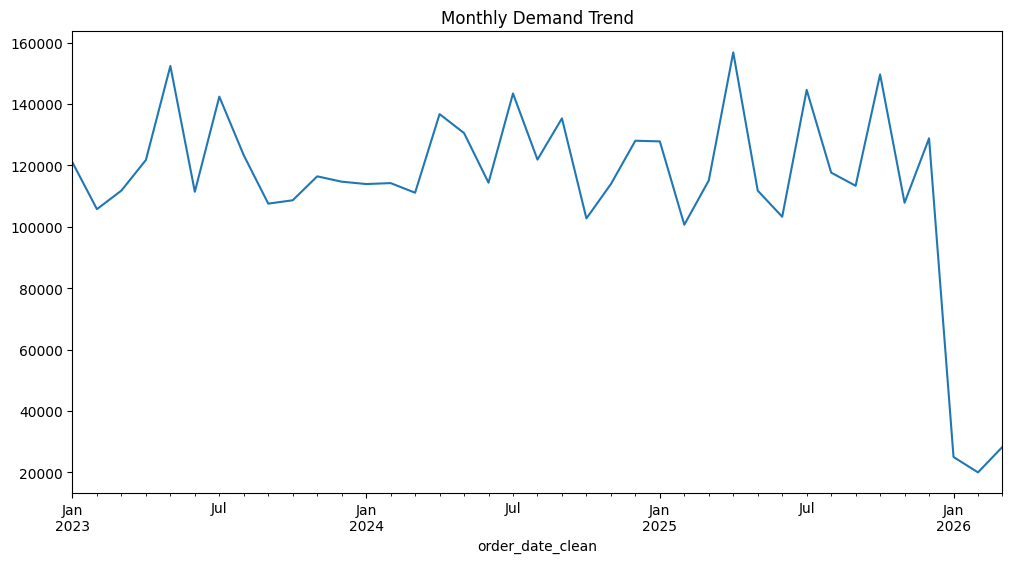

In [ ]:
# ==================================================
# Monthly Demand Trend
# ==================================================
import matplotlib.pyplot as plt
monthly_demand = (
    master_df
    .groupby(
        master_df["order_date_clean"]
        .dt.to_period("M")
    )["quantity_ordered"]
    .sum()
)

monthly_demand.plot(
    figsize=(12,6)
)

plt.title(
    "Monthly Demand Trend"
)

plt.show()

# QUARTERLY DEMAND PATTERN

In [ ]:
# ==================================================
# Quarterly Demand Pattern
# ==================================================

quarterly_demand = (
    master_df
    .groupby(
        master_df["order_date_clean"]
        .dt.to_period("Q")
    )["quantity_ordered"]
    .sum()
)

quarterly_demand

order_date_clean
2023Q1    338486
2023Q2    385556
2023Q3    373210
2023Q4    339757
2024Q1    339247
2024Q2    381610
2024Q3    400623
2024Q4    344674
2025Q1    343572
2025Q2    371860
2025Q3    375606
2025Q4    386284
2026Q1     73224
Freq: Q-DEC, Name: quantity_ordered, dtype: int64

# PEAK MONTHS BY CATEGORY

In [ ]:
# ==================================================
# Peak Demand Month By Category
# ==================================================

category_month = (
    master_df
    .groupby(
        [
            "category",
            master_df["order_date_clean"].dt.month
        ]
    )["quantity_ordered"]
    .sum()
    .reset_index()
)

category_month.head()

,category,order_date_clean,quantity_ordered
0,Accessories,1,71190
1,Accessories,2,77419
2,Accessories,3,92316
3,Accessories,4,70838
4,Accessories,5,90251


# REORDER POINT

In [ ]:
# ==================================================
# Reorder Point Calculation
# ==================================================

avg_daily_demand = (
    master_df
    .groupby("product_id")["quantity_ordered"]
    .mean()
)

lead_time = (
    products
    .set_index("product_id")
    ["lead_time_days"]
)

safety_stock = (
    inventory
    .groupby("product_id")
    ["safety_stock"]
    .mean()
)

reorder_analysis = pd.concat(
    [
        avg_daily_demand,
        lead_time,
        safety_stock
    ],
    axis=1
)

reorder_analysis.columns = [
    "avg_daily_demand",
    "lead_time",
    "safety_stock"
]

reorder_analysis["reorder_point_calc"] = (
    reorder_analysis["avg_daily_demand"]
    *
    reorder_analysis["lead_time"]
) + reorder_analysis["safety_stock"]

reorder_analysis.head()

,avg_daily_demand,lead_time,safety_stock,reorder_point_calc
product_id,,,,
P0001,197.318182,8,92.615385,1671.160839
P0002,232.647059,16,31.200000,3753.552941
P0003,258.028571,36,91.764706,9380.793277
P0004,288.000000,29,22.047619,8374.047619
P0005,256.791667,7,16.850000,1814.391667


# SUPPLIER ON-TIME DELIVERY RATE

In [44]:
# ==================================================
# On Time Delivery Rate
# ==================================================

supplier_otd = (
    master_df
    .groupby("supplier_name")
    ["delay_flag"]
    .mean()
    .reset_index()
)

supplier_otd["OTD_Rate"] = (
    1 - supplier_otd["delay_flag"]
) * 100

supplier_otd.head()

,supplier_name,delay_flag,OTD_Rate
0,Supplier_0001 Ltd,0.118182,88.181818
1,Supplier_0002 Pvt Ltd,0.130000,87.000000
2,Supplier_0003 Pvt Ltd,0.100917,89.908257
3,Supplier_0004 Pvt Ltd,0.090909,90.909091
4,Supplier_0005 Pvt Ltd,0.127119,87.288136


In [45]:
master_df.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'product_id',
 'warehouse_id_x',
 'supplier_id',
 'quantity_ordered',
 'unit_price',
 'unit_cost',
 'sales_amount',
 'cost_amount',
 'profit',
 'order_status',
 'shipping_days',
 'delivery_date_x',
 'order_date_clean',
 'delivery_date_clean_x',
 'rn_x',
 'missing_delivery_date_flag',
 'profit_margin_pct',
 'delay_flag',
 'days_since_last_order',
 'customer_name',
 'customer_segment',
 'city_x',
 'state_x',
 'join_date',
 'join_date_clean',
 'rn_y',
 'missing_city_flag',
 'city_clean',
 'product_name',
 'category',
 'subcategory',
 'brand',
 'launch_date',
 'reorder_point',
 'lead_time_days',
 'product_status',
 'supplier_name',
 'supplier_city',
 'supplier_state',
 'supplier_rating',
 'contract_start_date',
 'on_time_delivery_rate',
 'quality_score',
 'supplier_status',
 'warehouse_name',
 'city_y',
 'state_y',
 'capacity_units',
 'warehouse_manager',
 'warehouse_type',
 'shipment_id',
 'warehouse_id_y',
 'carrier_name',
 'dispatch_date',
 '

# ==================================================
# EXPORT TABLEAU DATASET
# ==================================================

In [ ]:
# ==================================================
# Create Tableau Ready Dataset
# ==================================================

drop_cols = [
    'rn_x',
    'rn_y',
    'city_clean',
    'missing_city_flag',
    'missing_delivery_date_flag'
]

master_tableau = master_df.drop(
    columns=drop_cols,
    errors='ignore'
)

print(master_tableau.shape)

(16958, 58)


In [ ]:
print(
    [c for c in master_df.columns if 'rn' in c.lower()]
)

print(
    [c for c in master_df.columns if 'missing' in c.lower()]
)

['rn_x', 'rn_y', 'rn']
['missing_delivery_date_flag', 'missing_city_flag']


In [ ]:
# ==================================================
# Export Tableau Dataset
# ==================================================

master_tableau.to_csv(
    "tableau_supply_chain_dataset.csv",
    index=False
)

print("Tableau Dataset Exported Successfully")

Tableau Dataset Exported Successfully


In [ ]:
print(master_tableau.shape)
print(master_tableau.columns.tolist())

(16958, 58)
['order_id', 'order_date', 'customer_id', 'product_id', 'warehouse_id_x', 'supplier_id', 'quantity_ordered', 'unit_price', 'unit_cost', 'sales_amount', 'cost_amount', 'profit', 'order_status', 'shipping_days', 'delivery_date_x', 'order_date_clean', 'delivery_date_clean_x', 'profit_margin_pct', 'delay_flag', 'days_since_last_order', 'customer_name', 'customer_segment', 'city_x', 'state_x', 'join_date', 'join_date_clean', 'product_name', 'category', 'subcategory', 'brand', 'launch_date', 'reorder_point', 'lead_time_days', 'product_status', 'supplier_name', 'supplier_city', 'supplier_state', 'supplier_rating', 'contract_start_date', 'on_time_delivery_rate', 'quality_score', 'supplier_status', 'warehouse_name', 'city_y', 'state_y', 'capacity_units', 'warehouse_manager', 'warehouse_type', 'shipment_id', 'warehouse_id_y', 'carrier_name', 'dispatch_date', 'delivery_date_y', 'shipping_cost', 'shipping_status', 'dispatch_date_clean', 'delivery_date_clean_y', 'rn']


In [ ]:
master_tableau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16958 entries, 0 to 16957
Data columns (total 58 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               16958 non-null  object        
 1   order_date             16958 non-null  object        
 2   customer_id            15232 non-null  object        
 3   product_id             16958 non-null  object        
 4   warehouse_id_x         16958 non-null  object        
 5   supplier_id            15237 non-null  object        
 6   quantity_ordered       16958 non-null  int64         
 7   unit_price             16958 non-null  float64       
 8   unit_cost              16958 non-null  float64       
 9   sales_amount           16958 non-null  float64       
 10  cost_amount            16958 non-null  float64       
 11  profit                 16958 non-null  float64       
 12  order_status           16958 non-null  object        
 13  s

In [ ]:
master_tableau.to_csv(
    "tableau_supply_chain_dataset.csv",
    index=False
)

## Inventory Analysis


In [46]:
for col in master_df.columns:
    if 'stock' in col.lower():
        print(col)

for col in master_df.columns:
    if 'inventory' in col.lower():
        print(col)

for col in master_df.columns:
    if 'safety' in col.lower():
        print(col)

for col in master_df.columns:
    if 'reorder' in col.lower():
        print(col)

reorder_point


In [47]:
inventory.columns

Index(['inventory_id', 'snapshot_date', 'warehouse_id', 'product_id',
       'stock_on_hand', 'reorder_point', 'safety_stock', 'inventory_value',
       'days_of_inventory', 'snapshot_date_clean', 'stockout_flag'],
      dtype='object')

In [48]:
print(inventory.columns.tolist())

['inventory_id', 'snapshot_date', 'warehouse_id', 'product_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'inventory_value', 'days_of_inventory', 'snapshot_date_clean', 'stockout_flag']


In [49]:
print(inventory.shape)

(7866, 11)
